WARNING    'rates' is an internal variable of group 'poisson_example', but also exists in the run namespace with the value array([10., 20., 30., 40., 50.]) * hertz. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Running simulation...
Simulation complete!


DimensionMismatchError: exp expects a dimensionless argument but got [-0.         -0.04749091 ... -4.65410909 -4.7016    ] Hz (unit is Hz).

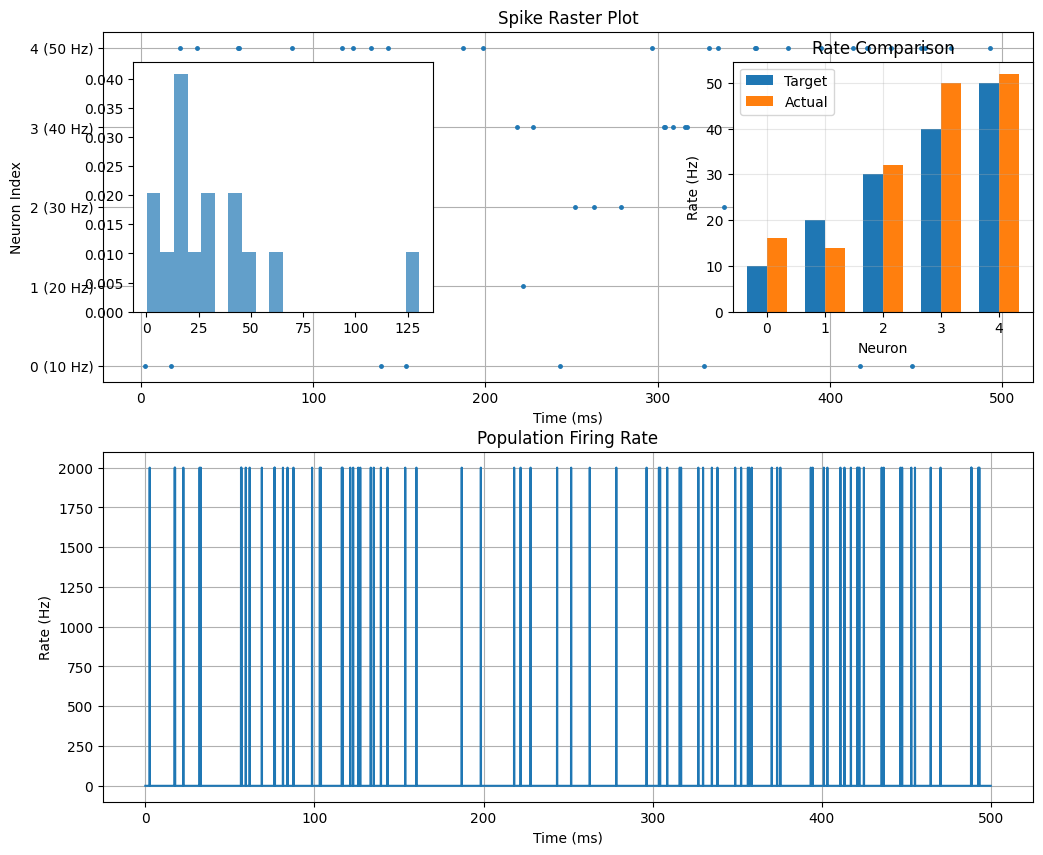

In [1]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Set up the simulation
defaultclock.dt = 0.1*ms
duration = 500*ms

# Create a group of 5 Poisson neurons
N = 5  # Number of neurons
rates = np.array([10, 20, 30, 40, 50]) * Hz  # Different rate for each neuron

# Define the neuron group
poisson_neurons = NeuronGroup(
    N, 
    'rates : Hz', 
    threshold='rand()<rates*dt',
    name="poisson_example"
)

# Set the firing rates
poisson_neurons.rates = rates

# Set up recording of spikes
spike_monitor = SpikeMonitor(poisson_neurons)
rate_monitor = PopulationRateMonitor(poisson_neurons)

# Create the network and add our objects
net = Network(poisson_neurons, spike_monitor, rate_monitor)

# Run the simulation
print("Running simulation...")
net.run(duration)
print("Simulation complete!")

# Create figure with multiple panels
fig = plt.figure(figsize=(12, 10))

# Plot 1: Raster plot of spikes
ax1 = plt.subplot(211)
plt.plot(spike_monitor.t/ms, spike_monitor.i, '.', markersize=5)
plt.title('Spike Raster Plot')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.grid(True)

# Add rate labels to y-axis
yticks = np.arange(N)
yticklabels = [f"{i} ({rates[i]/Hz:.0f} Hz)" for i in range(N)]
plt.yticks(yticks, yticklabels)

# Plot 2: Firing rates over time
ax2 = plt.subplot(212)
plt.plot(rate_monitor.t/ms, rate_monitor.rate/Hz)
plt.title('Population Firing Rate')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.grid(True)

# Plot 3: Average firing rates comparison
ax3 = plt.axes([0.65, 0.6, 0.25, 0.25])  # Inset plot
actual_rates = np.zeros(N)
for i in range(N):
    count = np.sum(spike_monitor.i == i)
    actual_rates[i] = count / (duration/second)

# Compare actual vs expected rates
x = np.arange(N)
bar_width = 0.35
ax3.bar(x - bar_width/2, rates/Hz, bar_width, label='Target')
ax3.bar(x + bar_width/2, actual_rates, bar_width, label='Actual')
ax3.set_xticks(x)
ax3.set_title('Rate Comparison')
ax3.set_xlabel('Neuron')
ax3.set_ylabel('Rate (Hz)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Show ISI distribution for one neuron
ax4 = plt.axes([0.15, 0.6, 0.25, 0.25])  # Inset plot
neuron_idx = 2  # Look at neuron #2 (30Hz)
spike_times = spike_monitor.t[spike_monitor.i == neuron_idx]/ms
if len(spike_times) > 1:
    isi = np.diff(spike_times)
    ax4.hist(isi, bins=20, density=True, alpha=0.7)
    
    # Plot theoretical exponential distribution
    x_range = np.linspace(0, max(isi)*1.2, 100)
    rate_in_ms = rates[neuron_idx]/1000
    y_exp = rate_in_ms * np.exp(-rate_in_ms * x_range)
    ax4.plot(x_range, y_exp, 'r-', lw=2)
    
    ax4.set_title(f'ISI Distribution (Neuron {neuron_idx})')
    ax4.set_xlabel('ISI (ms)')
    ax4.set_ylabel('Probability')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Not enough spikes', 
             horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics:")
print(f"{'Neuron':<10} {'Target Rate':<15} {'Actual Rate':<15} {'Spike Count':<15}")
print("-" * 55)
for i in range(N):
    count = np.sum(spike_monitor.i == i)
    print(f"{i:<10} {rates[i]/Hz:<15.2f} {actual_rates[i]:<15.2f} {count:<15}")

total_spikes = len(spike_monitor.i)
print(f"\nTotal spikes recorded: {total_spikes}")
print(f"Average population rate: {total_spikes/(duration/second)/N:.2f} Hz")